# Quantitative Trading Architecture: Centered Conditional Distillation & Dual-Engine Risk Forecasting

This architecture utilizes deep learning as a present-state classifier combined with Annealed Stochastic Gradient Langevin Dynamics (SGLD)[cite: 1, 3]. It strictly separates present-state classification from future-state trend projection and risk management[cite: 3].

Deep learning models (Gated Recurrent Units) evaluate the current market regime (Bull, Neutral, or Bear) using backward-looking technical features[cite: 3]. Future-state and trend tracking are delegated to a classical first-order Markov chain operating on centered return windows (11-day / $\pm5$-day and 3-day / $\pm1$-day horizons). A custom fractional step size ($\text{int}(\text{size}/3)$) is applied to the Markov transition matrices to eliminate overlapping window autocorrelation. Performance evaluation is handled via `quantstats` metrics[cite: 1, 2].

In [ ]:
!pip install TA-Lib mplfinance quantstats seaborn scikit-learn yfinance

import math
import copy
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import talib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import quantstats as qs
import itertools

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")

Using compute device: cuda


## Phase I: Data Engineering and Centered Regime Labelling

Feature construction relies exclusively on technical indicators computed from market data[cite: 3]. The seven-dimensional feature space comprises:
*   Relative Strength Index (14-day period)[cite: 3].
*   Stochastic Fast %K and Fast %D (periods 5 and 3)[cite: 3].
*   Normalised moving-average spread representing the 5-day and 20-day SMA difference over a 20-day rolling standard deviation[cite: 3].
*   Average Directional Index (14-day period)[cite: 3].
*   Distance from the 200-day simple moving average[cite: 3].
*   Volume ratio against a 20-day volume simple moving average[cite: 3].

Target labels evaluate the present state using **centered cumulative return windows** to better capture current trend momentum:
*   **3-Day Horizon:** $\pm1$-day centered return ($\text{Close}_{t+1} / \text{Close}_{t-1} - 1$).
*   **11-Day Horizon:** $\pm5$-day centered return ($\text{Close}_{t+5} / \text{Close}_{t-5} - 1$).

A 252-day rolling window assigns regimes dynamically using a 30-40-30 split[cite: 3]:
*   **State 0 (Bull):** Return exceeds the 70th percentile of the rolling window[cite: 3].
*   **State 1 (Neutral):** Return lies between the 30th and 70th percentiles[cite: 3].
*   **State 2 (Bear):** Return falls below the 30th percentile[cite: 3].

In [ ]:
class MarketDataPipeline:
    def __init__(self, ticker, start_date, end_date, time_steps_3d=3, time_steps_11d=11):
        self.ticker = ticker
        self.start_date = pd.to_datetime(start_date) - pd.Timedelta(days=400)
        self.end_date = end_date
        self.time_steps_3d = time_steps_3d
        self.time_steps_11d = time_steps_11d
        self.feature_columns = ['RSI', 'Fast_K', 'Fast_D', 'MA_Spread', 'ADX', '200D_MA_Dist', 'Vol_Ratio']

    def fetch_data(self):
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df

    def compute_features(self, df):
        df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
        fastk, fastd = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=5, fastd_period=3, fastd_matype=0)
        df['Fast_K'] = fastk
        df['Fast_D'] = fastd

        sma_5 = talib.SMA(df['Close'], timeperiod=5)
        sma_20 = talib.SMA(df['Close'], timeperiod=20)
        rolling_sd = df['Close'].rolling(window=20).std().replace(0, np.nan)
        df['MA_Spread'] = (sma_5 - sma_20) / rolling_sd

        df['ADX'] = talib.ADX(df['High'], df['Low'], df['Close'], timeperiod=14)
        sma_200 = talib.SMA(df['Close'], timeperiod=200)
        df['200D_MA_Dist'] = (df['Close'] - sma_200) / sma_200

        sma_vol_20 = talib.SMA(df['Volume'], timeperiod=20).replace(0, np.nan)
        df['Vol_Ratio'] = (df['Volume'] / sma_vol_20).fillna(1.0)

        df['5D_MA'] = sma_5
        df['20D_MA'] = sma_20
        return df

    def generate_labels(self, df, rolling_window=252):
        # Centered Cumulative Returns (+-1D for 3D, +-5D for 11D)
        df['Ret_3D_Centered'] = df['Close'].shift(-1) / df['Close'].shift(1) - 1.0
        df['Ret_11D_Centered'] = df['Close'].shift(-5) / df['Close'].shift(5) - 1.0

        upper_3d = df['Ret_3D_Centered'].rolling(window=rolling_window).quantile(0.70)
        lower_3d = df['Ret_3D_Centered'].rolling(window=rolling_window).quantile(0.30)
        df['Regime_3D'] = np.select(
            [(df['Ret_3D_Centered'] > upper_3d), (df['Ret_3D_Centered'] < lower_3d)],
            [0, 2], default=1
        )

        upper_11d = df['Ret_11D_Centered'].rolling(window=rolling_window).quantile(0.70)
        lower_11d = df['Ret_11D_Centered'].rolling(window=rolling_window).quantile(0.30)
        df['Regime_11D'] = np.select(
            [(df['Ret_11D_Centered'] > upper_11d), (df['Ret_11D_Centered'] < lower_11d)],
            [0, 2], default=1
        )
        return df.dropna()

    def prepare_data(self, test_days):
        raw_df = self.fetch_data()
        df = self.compute_features(raw_df)
        self.clean_df = self.generate_labels(df)

        features = self.clean_df[self.feature_columns].values
        labels_3d = self.clean_df['Regime_3D'].values
        labels_11d = self.clean_df['Regime_11D'].values

        # Build 3D sequences
        X_3D, Y_3D = [], []
        for i in range(len(features) - self.time_steps_3d + 1):
            X_3D.append(features[i:(i + self.time_steps_3d)])
            Y_3D.append(labels_3d[i + self.time_steps_3d - 1])

        # Build 11D sequences
        X_11D, Y_11D = [], []
        for i in range(len(features) - self.time_steps_11d + 1):
            X_11D.append(features[i:(i + self.time_steps_11d)])
            Y_11D.append(labels_11d[i + self.time_steps_11d - 1])

        # Convert to arrays
        X_3D, Y_3D = np.array(X_3D), np.array(Y_3D)
        X_11D, Y_11D = np.array(X_11D), np.array(Y_11D)

        # Align chronologically by trimming the 3D data to match the length of the 11D data
        min_len = min(len(X_3D), len(X_11D))
        X_3D, Y_3D = X_3D[-min_len:], Y_3D[-min_len:]
        X_11D, Y_11D = X_11D[-min_len:], Y_11D[-min_len:]
        self.clean_df = self.clean_df.iloc[-min_len:].copy()

        split_idx = min_len - test_days

        # 3D Train/Test Split
        X_train_3d, X_test_3d = X_3D[:split_idx], X_3D[split_idx:]
        Y_train_3d, Y_test_3d = Y_3D[:split_idx], Y_3D[split_idx:]

        # 11D Train/Test Split
        X_train_11d, X_test_11d = X_11D[:split_idx], X_11D[split_idx:]
        Y_train_11d, Y_test_11d = Y_11D[:split_idx], Y_11D[split_idx:]

        # Fit Scalers independently
        self.scaler_3d = StandardScaler()
        B3, T3, F3 = X_train_3d.shape
        X_train_3d_reshaped = X_train_3d.reshape(-1, F3)
        self.scaler_3d.fit(X_train_3d_reshaped)
        X_train_3d = self.scaler_3d.transform(X_train_3d_reshaped).reshape(B3, T3, F3)
        X_test_3d = self.scaler_3d.transform(X_test_3d.reshape(-1, F3)).reshape(X_test_3d.shape[0], T3, F3)

        self.scaler_11d = StandardScaler()
        B11, T11, F11 = X_train_11d.shape
        X_train_11d_reshaped = X_train_11d.reshape(-1, F11)
        self.scaler_11d.fit(X_train_11d_reshaped)
        X_train_11d = self.scaler_11d.transform(X_train_11d_reshaped).reshape(B11, T11, F11)
        X_test_11d = self.scaler_11d.transform(X_test_11d.reshape(-1, F11)).reshape(X_test_11d.shape[0], T11, F11)

        return (X_train_3d, X_test_3d, Y_train_3d, Y_test_3d,
                X_train_11d, X_test_11d, Y_train_11d, Y_test_11d, self.clean_df)

## Neural Network Architectures & Student Distillation Loss

The deep-learning core features independent teacher GRUs (hidden dimension 64) and student GRUs (hidden dimension 16) trained on the 3D and 11D centered targets[cite: 3].

Student model supervision uses temperature-scaled Kullback-Leibler divergence combined with hard cross-entropy loss:
$$L = a \cdot L_{hard} + (1 - a) \cdot L_{soft}$$

This formulation anchors predictions to reality while absorbing structural trend dynamics from the horizon-specific teachers[cite: 3].

In [ ]:
class RegimeGRU(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, output_size=3):
        super(RegimeGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        logits = self.fc(out[:, -1, :])
        return logits

class SGLDOptimizer(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, noise_scale=0.01, weight_decay=1e-4):
        defaults = dict(lr=lr, noise_scale=noise_scale, weight_decay=weight_decay)
        super(SGLDOptimizer, self).__init__(params, defaults)

    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                if group['weight_decay'] != 0:
                    p.grad.data.add_(p.data, alpha=group['weight_decay'])
                lr = group['lr']
                noise = torch.randn_like(p.data) * math.sqrt(2.0 * lr) * group['noise_scale']
                p.data.add_(p.grad.data, alpha=-lr)
                p.data.add_(noise)
        return loss

def single_teacher_distillation_loss(student_logits, teacher_logits, true_labels, a=0.6, temp=2.0):
    hard_loss = F.cross_entropy(student_logits, true_labels, reduction='none')

    soft_loss = F.kl_div(
        F.log_softmax(student_logits / temp, dim=1),
        F.softmax(teacher_logits / temp, dim=1),
        reduction='none'
    ).sum(dim=1) * (temp ** 2)

    total_loss = (a * hard_loss) + ((1.0 - a) * soft_loss)

    return total_loss.mean()

## Checkpoint 1 - Teacher Model Validation

The 3-day and 11-day teachers are supervised independently on their respective centered time horizons and trained for 150 epochs using standard cross-entropy and the Adam optimizer[cite: 3]. Confusion matrices verify feature-target compatibility on the training set[cite: 1, 3].

In [ ]:
def train_teacher(model, X_train, Y_train, epochs=150, lr=1e-3):
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=96, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx.to(DEVICE)), by.to(DEVICE))
            loss.backward()
            optimizer.step()
    model.eval()

def plot_teacher_confusion_matrices(teacher_3d, teacher_11d, X_train_3d, X_train_11d, Y_train_3d, Y_train_11d):
    print("\n--- CHECKPOINT 1: Teacher Model Validation ---")
    X_tensor_3d = torch.tensor(X_train_3d, dtype=torch.float32).to(DEVICE)
    X_tensor_11d = torch.tensor(X_train_11d, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        preds_3d = torch.argmax(teacher_3d(X_tensor_3d), dim=1).cpu().numpy()
        preds_11d = torch.argmax(teacher_11d(X_tensor_11d), dim=1).cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(confusion_matrix(Y_train_3d, preds_3d), annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['Bull', 'Neutral', 'Bear'], yticklabels=['Bull', 'Neutral', 'Bear'])
    ax[0].set_title("3D Teacher (Training CM)")

    sns.heatmap(confusion_matrix(Y_train_11d, preds_11d), annot=True, fmt='d', cmap='Reds', ax=ax[1],
                xticklabels=['Bull', 'Neutral', 'Bear'], yticklabels=['Bull', 'Neutral', 'Bear'])
    ax[1].set_title("11D Teacher (Training CM)")
    plt.tight_layout()
    plt.show()

## Checkpoint 2 - Annealed Stochastic Gradient Langevin Dynamics (SGLD)

Student model distillation happens in two phases. Phase 1 runs a 150-epoch burn-in with Adam to quickly locate a promising loss basin[cite: 3]. Phase 2 switches to SGLD with reduced noise to generate an ensemble[cite: 3].

Deep copies of model weights are collected at thinning intervals (every 5 epochs) to compute mean regime probabilities and 90% confidence uncertainty spreads[cite: 1, 3].

In [ ]:
def train_single_student_annealed(student, teacher, X_train, Y_train, title, epochs=300, burn_in=150, thinning=5):
    print(f"\n--- CHECKPOINT 2: Training SGLD Student ({title}) ---")
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=96, shuffle=True)

    optimizer_adam = torch.optim.Adam(student.parameters(), lr=1e-3)
    optimizer_sgld = SGLDOptimizer(student.parameters(), lr=5e-4, noise_scale=0.005)

    mc_samples = []

    for epoch in range(epochs):
        student.train()
        current_optimizer = optimizer_adam if epoch < burn_in else optimizer_sgld

        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            with torch.no_grad():
                teacher_logits = teacher(bx)

            current_optimizer.zero_grad()
            student_logits = student(bx)
            loss = single_teacher_distillation_loss(student_logits, teacher_logits, by, a=0.6)
            loss.backward()
            current_optimizer.step()

        if epoch >= burn_in and epoch % thinning == 0:
            mc_samples.append({k: v.cpu() for k, v in copy.deepcopy(student.state_dict()).items()})

    print(f"Collected {len(mc_samples)} MC Weight Samples for {title}.")

    student.eval()
    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for state in mc_samples:
            student.load_state_dict(state)
            all_probs.append(F.softmax(student(X_tensor), dim=1).cpu().numpy())

    mean_probs = np.mean(np.array(all_probs), axis=0)
    student_preds = np.argmax(mean_probs, axis=1)

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(Y_train, student_preds), annot=True, fmt='d', cmap='Purples',
                xticklabels=['Bull', 'Neutral', 'Bear'], yticklabels=['Bull', 'Neutral', 'Bear'])
    plt.title(f"Student Model ({title} - Training CM)")
    plt.show()
    return mc_samples

def predict_intervals(student, mc_samples, X):
    X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for state in mc_samples:
            student.load_state_dict(state)
            all_probs.append(F.softmax(student(X_tensor), dim=1).cpu().numpy())

    all_probs = np.array(all_probs)
    mean_probs = np.mean(all_probs, axis=0)
    spreads = np.percentile(all_probs, 95, axis=0) - np.percentile(all_probs, 5, axis=0)
    return mean_probs, spreads

## Phase II: The Fractional-Step Markov Forecasting Engine

To prevent massive autocorrelation caused by overlapping centered windows, first-order Markov transition matrices $T$ are estimated empirically using a custom step size of $\text{max}(1, \text{int}(\text{size}/3))$ based on training label sequences[cite: 3].

One-step-ahead forecasts are produced via matrix-vector products[cite: 3]. This provides robust transition probabilities without introducing forward-looking bias into the neural networks[cite: 3].

In [ ]:
class MarkovForecaster:
    def __init__(self, step_size=1):
        self.transition_matrix = np.zeros((3, 3))
        self.step_size = step_size

    def fit(self, Y_train):
        for (i, j) in zip(Y_train[:-self.step_size], Y_train[self.step_size:]):
            self.transition_matrix[i, j] += 1
        row_sums = self.transition_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        self.transition_matrix = self.transition_matrix / row_sums

    def forecast(self, present_probs):
        return np.dot(present_probs, self.transition_matrix)

## Checkpoint 3 - Dual-Engine Decoupled Risk & Execution Logic

This executes a parallel **Committee Consensus Entry** and an **Any-Veto Exit** architecture to decouple risk management from alpha generation:
*   **Hold / Roll (Entry):** Evaluated daily. At least one model must be highly confident (spread < threshold), and at least one model must vote Bull without the other voting Bear[cite: 3].
*   **Forced Liquidation (Veto):** Trades are exited immediately if *either* model flashes a Bear signal, OR if *both* models experience a spread blowout (indicating extreme, unreadable market chaos)[cite: 3].

In [ ]:
def run_dual_engine_backtest(clean_df, test_days, forecasts_11d, spreads_11d, forecasts_3d, spreads_3d):
    print(f"\n--- CHECKPOINT 3: Parallel Dual-Engine Backtest & Charting ---")
    data = clean_df.iloc[-test_days:].copy()

    # Load parameters for both models
    data['Spread_11D'] = np.max(spreads_11d, axis=1)
    data['Bull_Prob_11D'] = forecasts_11d[:, 0]
    data['Bear_Prob_11D'] = forecasts_11d[:, 2]

    data['Spread_3D'] = np.max(spreads_3d, axis=1)
    data['Bull_Prob_3D'] = forecasts_3d[:, 0]
    data['Bear_Prob_3D'] = forecasts_3d[:, 2]

    cash = INITIAL_WEALTH
    holdings = 0.0
    in_position = False

    strategy_values = []
    buy_markers = [np.nan] * len(data)
    sell_markers = [np.nan] * len(data)

    start_price = data['Close'].iloc[0]
    data['Benchmark_Value'] = data['Close'] * (INITIAL_WEALTH / start_price)

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        open_price = data['Open'].iloc[i]

        if i == 0:
            strategy_values.append(INITIAL_WEALTH)
            continue

        prev = data.iloc[i-1]

        bull_11d = prev['Bull_Prob_11D']
        bear_11d = prev['Bear_Prob_11D']
        spr_11d  = prev['Spread_11D']

        bull_3d = prev['Bull_Prob_3D']
        bear_3d = prev['Bear_Prob_3D']
        spr_3d  = prev['Spread_3D']

        # --- CORE AI LOGIC: 8-THRESHOLD ASYMMETRIC GATES ---

        # 1. Entry Gates (Require probability > threshold AND spread < threshold)
        bull_3d_active = (bull_3d > BUY_PROB_3D) and (spr_3d < BUY_SPREAD_3D)
        bull_11d_active = (bull_11d > BUY_PROB_11D) and (spr_11d < BUY_SPREAD_11D)

        # 2. Bear Veto Gates
        bear_3d_active = bear_3d > SELL_BEAR_PROB_3D
        bear_11d_active = bear_11d > SELL_BEAR_PROB_11D
        any_bear = bear_3d_active or bear_11d_active

        # 3. Neutral + Spread Blowout Veto Gates
        neutral_3d_blown = (not bull_3d_active and not bear_3d_active) and (spr_3d > SELL_SPREAD_3D)
        neutral_11d_blown = (not bull_11d_active and not bear_11d_active) and (spr_11d > SELL_SPREAD_11D)

        # --- EXECUTION DECISIONS ---
        # BUY: Either engine triggers an active bull signal.
        go_long = (bull_3d_active or bull_11d_active)

        # SELL: Either engine triggers bear OR is neutral but spread exceeds safety threshold.
        force_liquidate = any_bear or neutral_3d_blown or neutral_11d_blown

        # --- DAILY EXECUTION ---
        if go_long and not force_liquidate and not in_position:
            execution_price = open_price * (1 + TRANSACTION_FEE)
            holdings = cash / execution_price
            cash = 0.0
            in_position = True
            buy_markers[i] = data['Low'].iloc[i] * 0.99

        elif force_liquidate and in_position:
            execution_price = open_price * (1 - TRANSACTION_FEE)
            cash = holdings * execution_price
            holdings = 0.0
            in_position = False
            sell_markers[i] = data['High'].iloc[i] * 1.01

        strategy_values.append(cash + (holdings * price))

    data['Strategy_Value'] = strategy_values

    strat_ret = data['Strategy_Value'].pct_change().dropna()
    bench_ret = data['Benchmark_Value'].pct_change().dropna()

    strat_ret.index = pd.to_datetime(strat_ret.index)
    bench_ret.index = pd.to_datetime(bench_ret.index)

    print("\n=== QuantStats Tear Sheet ===")
    qs.reports.metrics(strat_ret, benchmark=bench_ret, prepare_returns=False)

    # Visualization
    apds = [
        mpf.make_addplot(data['5D_MA'], color='blue', panel=0, width=1.0),
        mpf.make_addplot(data['20D_MA'], color='orange', panel=0, width=1.0),
        mpf.make_addplot(data['Volume'], type='bar', color='gray', panel=1, ylabel='Vol', alpha=0.5),
        mpf.make_addplot(data['Spread_11D'], color='blue', panel=2, ylabel='11D Spread'),
        mpf.make_addplot([BUY_SPREAD_11D]*len(data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([SELL_SPREAD_11D]*len(data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(data['Spread_3D'], color='orange', panel=3, ylabel='3D Spread'),
        mpf.make_addplot([BUY_SPREAD_3D]*len(data), color='green', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot([SELL_SPREAD_3D]*len(data), color='red', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot(data['Strategy_Value'], panel=4, color='darkgreen', ylabel='Equity', width=1.5),
        mpf.make_addplot(data['Benchmark_Value'], panel=4, color='gray', linestyle='--', width=1.0)
    ]

    if pd.Series(buy_markers).notna().any():
        apds.append(mpf.make_addplot(buy_markers, type='scatter', markersize=60, marker='^', color='lime', panel=0))
    if pd.Series(sell_markers).notna().any():
        apds.append(mpf.make_addplot(sell_markers, type='scatter', markersize=60, marker='v', color='red', panel=0))

    mpf.plot(data, type='candle', addplot=apds, panel_ratios=(4, 1, 1, 1, 2), figratio=(12, 14), figscale=1.3, title=f'\nDual-Engine Committee Backtest')

## Checkpoint 4 - Generalized 2D Heatmaps

Partial-dependence heat-maps are mapped automatically for all 21 possible feature pairings[cite: 1, 3]. This visualizes the underlying non-linear decision boundaries of the student networks across various market dimensions[cite: 3].

In [ ]:
def plot_all_2d_pdp_heatmaps(student_model, scaler, feature_names, X_train):
    print("\n--- GENERATING ALL 21 2D DECISION BOUNDARY HEATMAPS ---")

    feature_pairs = list(itertools.combinations(feature_names, 2))

    X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_train_orig = scaler.inverse_transform(X_train_reshaped)
    medians = np.median(X_train_orig, axis=0)

    student_model.eval()

    for f_x, f_y in feature_pairs:
        idx_x = feature_names.index(f_x)
        idx_y = feature_names.index(f_y)

        x_min, x_max = np.percentile(X_train_orig[:, idx_x], [5, 95])
        y_min, y_max = np.percentile(X_train_orig[:, idx_y], [5, 95])

        x_range = np.linspace(x_min, x_max, 40)
        y_range = np.linspace(y_min, y_max, 40)
        XX, YY = np.meshgrid(x_range, y_range)

        Z_bull = np.zeros(XX.shape)
        Z_bear = np.zeros(XX.shape)

        for i in range(XX.shape[0]):
            for j in range(XX.shape[1]):
                features = medians.copy()
                features[idx_x] = XX[i, j]
                features[idx_y] = YY[i, j]

                seq = np.tile(features, (3, 1))
                seq_scaled = scaler.transform(seq)
                t_input = torch.tensor(seq_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    probs = F.softmax(student_model(t_input), dim=1).cpu().numpy()[0]
                    Z_bull[i, j] = probs[0]
                    Z_bear[i, j] = probs[2]

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        c1 = ax[0].contourf(XX, YY, Z_bull, levels=20, cmap='Greens')
        ax[0].set_title('Probability of BULL Regime')
        ax[0].set_xlabel(f_x)
        ax[0].set_ylabel(f_y)
        fig.colorbar(c1, ax=ax[0])

        c2 = ax[1].contourf(XX, YY, Z_bear, levels=20, cmap='Reds')
        ax[1].set_title('Probability of BEAR Regime')
        ax[1].set_xlabel(f_x)
        ax[1].set_ylabel(f_y)
        fig.colorbar(c2, ax=ax[1])

        plt.suptitle(f"Decision Boundary Heatmaps: {f_x} vs {f_y}", fontsize=14, y=1.03)
        plt.tight_layout()
        plt.show()

## Execution Phase: Data Prep & Teacher Constraints

The pipeline initiates by constructing features and centered target labels from historical ticker data[cite: 1]. Both 3-day ($\pm1$D) and 11-day ($\pm5$D) teachers are established to learn robust historical features across different trend horizons[cite: 1, 3].

Preparing Centered Data Pipeline...

--- CHECKPOINT 1: Teacher Model Validation ---


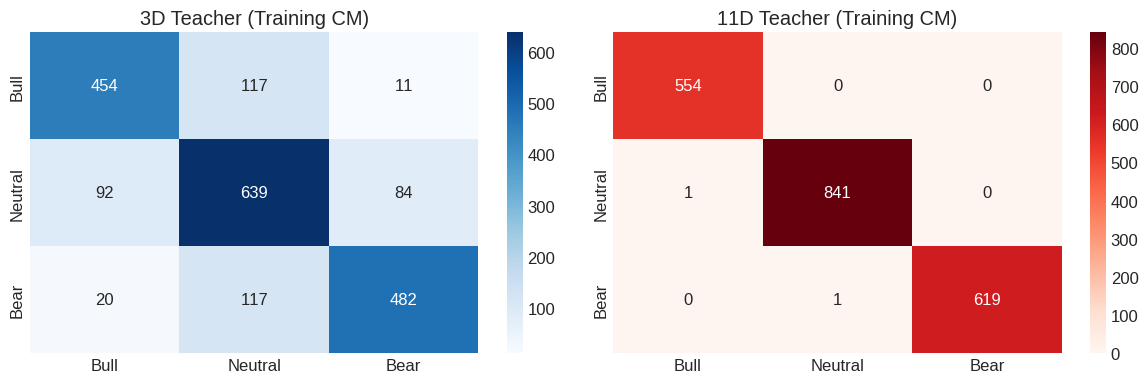

In [ ]:
TICKER = "^HSI"
START_DATE = "2011-01-01"
END_DATE = "2021-01-01"
TEST_DAYS_N = 504

print("Preparing Centered Data Pipeline...")
pipeline = MarketDataPipeline(ticker=TICKER, start_date=START_DATE, end_date=END_DATE, time_steps_3d=3, time_steps_11d=11)

(X_train_3d, X_test_3d, Y_train_3d, Y_test_3d,
 X_train_11d, X_test_11d, Y_train_11d, Y_test_11d, clean_df) = pipeline.prepare_data(test_days=TEST_DAYS_N)

input_size = X_train_3d.shape[2]

# --- TEACHER TRAINING ---
t3 = RegimeGRU(input_size, 96, 1).to(DEVICE)
t11 = RegimeGRU(input_size, 96, 1).to(DEVICE)

train_teacher(t3, X_train_3d, Y_train_3d, epochs=150)
train_teacher(t11, X_train_11d, Y_train_11d, epochs=150)

plot_teacher_confusion_matrices(t3, t11, X_train_3d, X_train_11d, Y_train_3d, Y_train_11d)

## Execution Phase: Student Distillation

Training executes 300 total epochs, splitting halfway at 150 for Adam to SGLD transitions[cite: 1, 3]. Monte-Carlo intervals evaluate prediction spreads for reliable inference capabilities across both time horizons[cite: 1, 3].


--- CHECKPOINT 2: Training SGLD Student (3D Student) ---
Collected 30 MC Weight Samples for 3D Student.


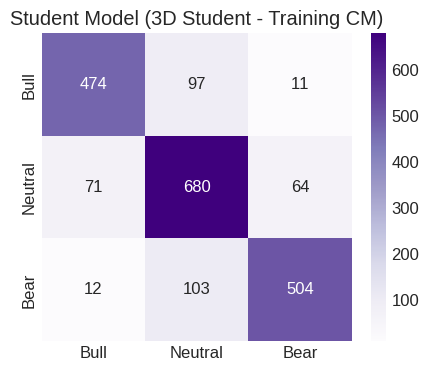


--- CHECKPOINT 2: Training SGLD Student (11D Student) ---
Collected 30 MC Weight Samples for 11D Student.


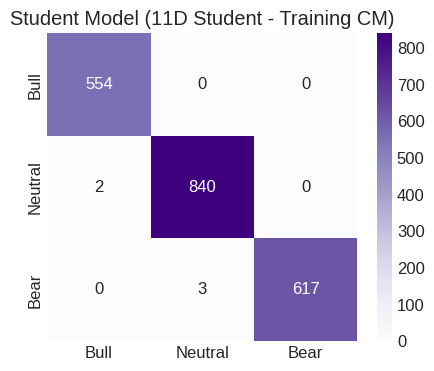


Markov Step Sizes -> 3D: 1, 11D: 3


In [ ]:
# --- DECOUPLED STUDENT SGLD DISTILLATION ---
student_3d = RegimeGRU(input_size, 96, 1).to(DEVICE)
student_11d = RegimeGRU(input_size, 96, 1).to(DEVICE)

mc_samples_3d = train_single_student_annealed(student_3d, t3, X_train_3d, Y_train_3d, "3D Student")
mc_samples_11d = train_single_student_annealed(student_11d, t11, X_train_11d, Y_train_11d, "11D Student")

# Predict Spreads & Probabilities on the Test Set
mean_probs_3d, spreads_3d = predict_intervals(student_3d, mc_samples_3d, X_test_3d)
mean_probs_11d, spreads_11d = predict_intervals(student_11d, mc_samples_11d, X_test_11d)

# --- DUAL MARKOV FORECASTERS (with size/3 step size logic) ---
step_size_3d = max(1, int(3 / 3))
step_size_11d = max(1, int(11 / 3))

print(f"\nMarkov Step Sizes -> 3D: {step_size_3d}, 11D: {step_size_11d}")

markov_3d = MarkovForecaster(step_size=step_size_3d)
markov_3d.fit(Y_train_3d)
forecasts_3d = markov_3d.forecast(mean_probs_3d)

markov_11d = MarkovForecaster(step_size=step_size_11d)
markov_11d.fit(Y_train_11d)
forecasts_11d = markov_11d.forecast(mean_probs_11d)

## Execution Phase: Dual-Engine Markov Backtesting

Incorporating the projected market regime probabilities and spreads, the `run_dual_engine_backtest` processes both sets of forecasts simultaneously to execute the decoupled Entry/Liquidation logic, displaying performance metrics visually[cite: 1].


--- CHECKPOINT 3: Parallel Dual-Engine Backtest & Charting ---

=== QuantStats Tear Sheet ===

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2018-12-14   2018-12-14
End Period           2020-12-23   2020-12-23
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       73.0%

Cumulative Return    -0.68%       -5.75%
CAGR﹪               -0.35%       -2.94%

Sharpe               0.08         -0.1
Prob. Sharpe Ratio   54.59%       44.57%
Sortino              0.11         -0.13
Sortino/√2           0.08         -0.09
Omega                1.01         0.98

Max Drawdown         -28.06%      -26.52%
Max DD Date          2020-03-23   2020-03-23
Max DD Period Start  2019-04-10   2019-03-20
Max DD Period End    2020-12-23   2020-12-23
Longest DD Days      624      

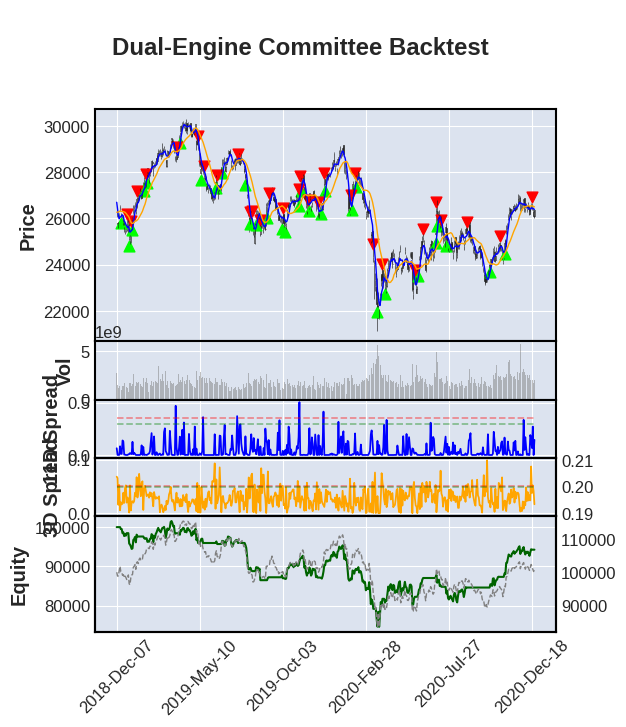

In [ ]:
# --- EXECUTION VARIABLES ---

# Entry Thresholds
BUY_PROB_3D    = 0.45
BUY_SPREAD_3D  = 0.20
BUY_PROB_11D   = 0.65
BUY_SPREAD_11D = 0.30

# Exit/Veto Thresholds
SELL_BEAR_PROB_3D  = 0.60
SELL_SPREAD_3D     = 0.05
SELL_BEAR_PROB_11D = 0.65
SELL_SPREAD_11D    = 0.35

TRANSACTION_FEE = 0.00005
INITIAL_WEALTH = 100000

# --- RUN THE DUAL-ENGINE BACKTEST ---
run_dual_engine_backtest(
    clean_df=clean_df,
    test_days=TEST_DAYS_N,
    forecasts_11d=forecasts_11d,
    spreads_11d=spreads_11d,
    forecasts_3d=forecasts_3d,
    spreads_3d=spreads_3d
)